# Exploratory Data Analysis
### Location: sg (Singapore)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
#visualization parameters
sns.set_theme(style='whitegrid')

In [3]:
#target IP to readable label mapping
TARGET_LABEL = {
    '8.8.8.8' : 'Google DNS (8.8.8.8)',
    '1.1.1.1' : 'Cloudflare DNS (1.1.1.1)',
    '94.140.14.14' : 'AdGuard DNS (94.140.14.14)',
    '185.222.222.222' : 'DNS.SB Europe (185.222.222.222)',
    '45.11.45.11' : 'DNS.SB Europe (45.11.45.11)'
}

In [4]:
#load dataset
active_df = pd.read_csv('../data/raw/active_probe_raw_2026_07_w2.csv')
passive_df = pd.read_csv('../data/raw/passive_probe_raw_2026_07_w2.csv')

In [5]:
#parse timestamp
active_df['timestamp'] = pd.to_datetime(active_df['timestamp'])
passive_df['timestamp'] = pd.to_datetime(passive_df['timestamp'])

In [6]:
print(f"Active Probe shape: {active_df.shape}")
print(f"Passive Probe shape: {passive_df.shape}\n")
print(f"Collection Period: {active_df.timestamp.min()} -> {active_df.timestamp.max()}")

Active Probe shape: (72900, 11)
Passive Probe shape: (472660, 11)

Collection Period: 2026-07-06 03:29:19 -> 2026-07-12 12:32:47


In [7]:
print("Active Probe INFO:")
active_df.info()

print("\nPassive Probe INFO:")
passive_df.info()

Active Probe INFO:
<class 'pandas.DataFrame'>
RangeIndex: 72900 entries, 0 to 72899
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        72900 non-null  datetime64[us]
 1   experiment_id    72900 non-null  str           
 2   source_location  72900 non-null  str           
 3   protocol         72900 non-null  str           
 4   dst_ip           72900 non-null  str           
 5   packet_size      72900 non-null  int64         
 6   probe_index      72900 non-null  int64         
 7   success          72900 non-null  bool          
 8   rtt_ms           42065 non-null  float64       
 9   send_timestamp   72900 non-null  float64       
 10  recv_timestamp   42065 non-null  float64       
dtypes: bool(1), datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 5.6 MB

Passive Probe INFO:
<class 'pandas.DataFrame'>
RangeIndex: 472660 entries, 0 to 472659
Data columns (total 

In [8]:
print("Missing Values - ACTIVE: ")
print(active_df.isnull().sum())

print("\nMissing Values - PASSIVE: ")
print(passive_df.isnull().sum())

Missing Values - ACTIVE: 
timestamp              0
experiment_id          0
source_location        0
protocol               0
dst_ip                 0
packet_size            0
probe_index            0
success                0
rtt_ms             30835
send_timestamp         0
recv_timestamp     30835
dtype: int64

Missing Values - PASSIVE: 
timestamp                    0
src_ip                       0
dst_ip                       0
protocol                     0
packet_length                0
ttl                          0
tcp_flag                343924
window_size             343924
source_location              0
experiment_id                0
experiment_timestamp         0
dtype: int64


**Comment**: `rtt_ms`, `recv_timestamp` null in active probe is expected and they correspond to the failed probes (timeout).
`tcp_flag`, `window_size` null in passive probes is expected as these fields exist only for TCP packet.

### ACTIVE CAPTURE 

In [9]:
print("Experiment Coverage: ")
print(f"Protocols: {active_df.protocol.unique().tolist()}")
print(f"Packet Size: {sorted(active_df.packet_size.unique().tolist())}")
print(f"Target: {active_df.dst_ip.unique().tolist()}")
print(f"Location: {active_df.source_location.unique().tolist()}")
print(f"\nTotal Experiment: {active_df.experiment_id.nunique()}")
print(f"Probes per Experiment: {active_df.groupby('experiment_id').size().unique().tolist()}")

Experiment Coverage: 
Protocols: ['tcp', 'icmp', 'udp']
Packet Size: [64, 128, 256, 512, 1024, 1400]
Target: ['8.8.8.8', '1.1.1.1', '94.140.14.14', '185.222.222.222', '45.11.45.11']
Location: ['sg']

Total Experiment: 2430
Probes per Experiment: [30]


In [10]:
success_summary = active_df.groupby('protocol')['success'].agg(
    total='count',
    successful='sum',
    success_rate='mean'
).round(4)
success_summary['success_rate'] = (success_summary['success_rate'] * 100).round(2).astype(str) + "%"
print(success_summary)

          total  successful success_rate
protocol                                
icmp      24300       24269       99.87%
tcp       24300           0         0.0%
udp       24300       17796       73.23%


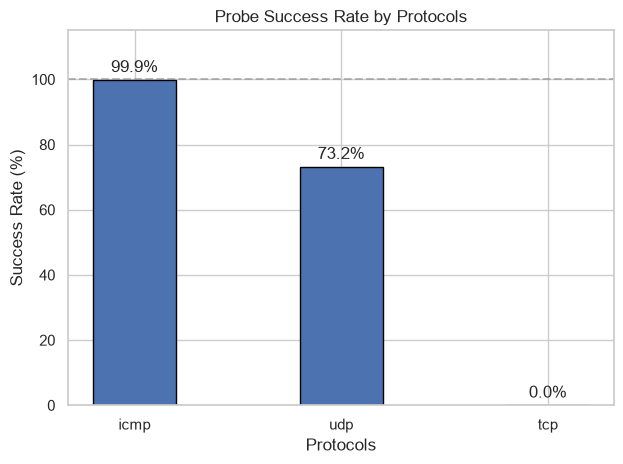

In [11]:
fig, ax = plt.subplots()
protocols = ["icmp", "udp", "tcp"]
success_rates = [
    active_df[active_df.protocol == 'icmp']['success'].mean() * 100,
    active_df[active_df.protocol == 'udp']['success'].mean() * 100,
    active_df[active_df.protocol == 'tcp']['success'].mean() * 100
]

bar = ax.bar(protocols, success_rates, edgecolor='black', width=0.4)
ax.bar_label(bar, fmt='%.1f%%', padding=3)
ax.set_ylim(0, 115)
ax.set_title("Probe Success Rate by Protocols")
ax.set_ylabel("Success Rate (%)")
ax.set_xlabel("Protocols")
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()

TCP has 0.00% success rate - all TCP probes timed out. This is not a data collection bug; Singapore server blocks raw TCP SYN packets crafted by scapy. ICMP acheives near-perfect 99.8% success confirming the network path is healthy. UDP success rate is 73.23% - the rest 26.77% is target-specific firewall filtering, not network congestion. Since we have 0.00% success rate for TCP, it will be excluded from further analysis and won't be considered while training the model as well.

In [12]:
#isolate clean successful non-TCP probes
success_df = active_df[(active_df['success'] == True) & (active_df['protocol'] != 'tcp')].copy()

print(f"Clean successful probes: {len(success_df)}")
print(f"Protocol breakdown: {success_df.protocol.value_counts().to_dict()}")

Clean successful probes: 42065
Protocol breakdown: {'icmp': 24269, 'udp': 17796}


In [13]:
zero_rtt = success_df[success_df['rtt_ms'] == 0]
outliers = success_df[success_df['rtt_ms'] > 500]

print(f"Zero RTT rows: {len(zero_rtt)}  ({len(zero_rtt) / len(success_df) * 100:.1f}%)")
print(f"Outliers  >500: {len(outliers)}\n")
print("Zero RTT by protocols: ")
print(zero_rtt.groupby('protocol').size())
print("\nOutlier details: ")
print(outliers[['protocol', 'dst_ip', 'packet_size', 'rtt_ms']])

Zero RTT rows: 4940  (11.7%)
Outliers  >500: 20

Zero RTT by protocols: 
protocol
icmp    3672
udp     1268
dtype: int64

Outlier details: 
      protocol           dst_ip  packet_size  rtt_ms
3490      icmp          1.1.1.1          256   516.0
10649      udp      45.11.45.11           64  2219.0
10657      udp      45.11.45.11          128  1047.0
19635     icmp          1.1.1.1           64  1125.0
19921      udp          1.1.1.1         1024   562.0
27347     icmp          8.8.8.8         1400   625.0
50573     icmp  185.222.222.222         1400   516.0
50582      udp  185.222.222.222           64   687.0
50636      udp  185.222.222.222          128   578.0
50742      udp  185.222.222.222         1400   516.0
50745      udp  185.222.222.222         1400   610.0
50991     icmp      45.11.45.11          128   609.0
51066     icmp      45.11.45.11         1024   594.0
51077     icmp      45.11.45.11         1024   656.0
51108     icmp      45.11.45.11         1400   563.0
51111     ic

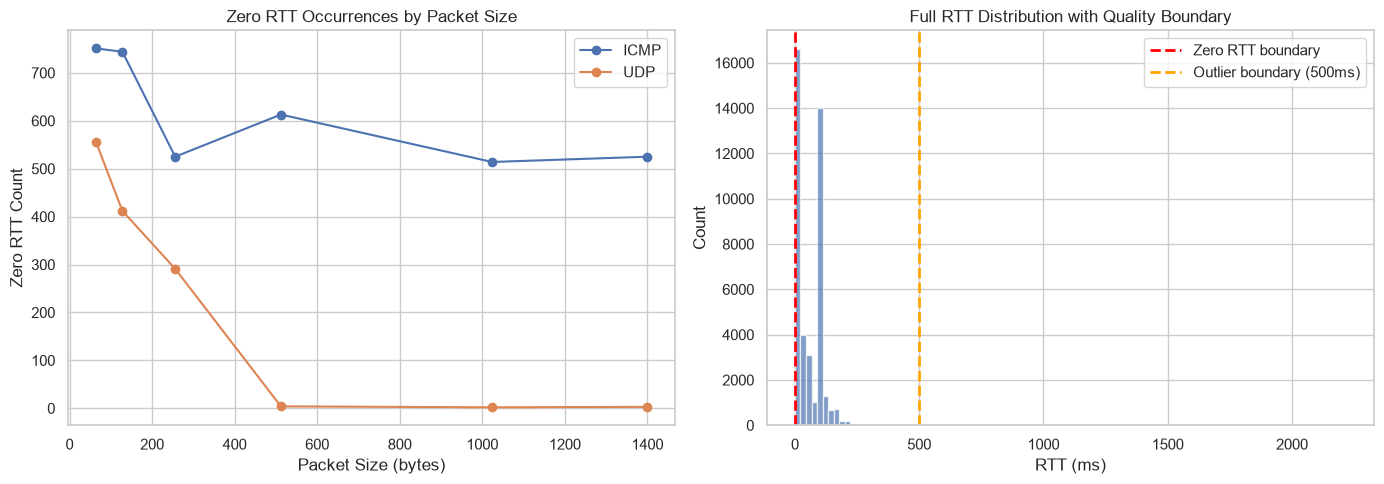

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# zero RTT distribution across packet size
zero_by_size = zero_rtt.groupby(['protocol', 'packet_size']).size().reset_index(name='count')
for proto in zero_by_size.protocol.unique():
    d = zero_by_size[zero_by_size.protocol == proto]
    axes[0].plot(d['packet_size'], d['count'], marker='o', label=proto.upper())
axes[0].set_title('Zero RTT Occurrences by Packet Size')
axes[0].set_xlabel('Packet Size (bytes)')
axes[0].set_ylabel('Zero RTT Count')
axes[0].legend()

# full RTT distribution with outliers and zero regions marked
axes[1].hist(success_df['rtt_ms'], bins=100, alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero RTT boundary')
axes[1].axvline(x=500, color='orange', linestyle='--', linewidth=2, label='Outlier boundary (500ms)')
axes[1].set_title('Full RTT Distribution with Quality Boundary')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('RTT (ms)')
axes[1].legend()

plt.tight_layout()

4940 successful probes have RTT = 0ms - physically impossible. This is a Scapy artifact where time.monotonic() records identical send and receive timestamps on sub-millisecond responses. Zero RTT values are concentrated in the ICMP probes (74.33%).These must be removed before any regression or statistical analysis as they will bias the mean downwards and corrupts D_trans slope estimation. The outliers are network anomilies, not representative measurements. Both will be dropped in preprocessing

In [15]:
clean_df = success_df[(success_df['rtt_ms'] > 0) & (success_df['rtt_ms'] <= 500)].copy()

print(f"Rows before cleaning = {len(success_df)}")
print(f"Rows after cleaning = {len(clean_df)}")
print(f"Rows removed = {len(success_df) - len(clean_df)} ({(1 - len(clean_df)/len(success_df))*100:.1f}%)")

Rows before cleaning = 42065
Rows after cleaning = 37105
Rows removed = 4960 (11.8%)


In [16]:
print("RTT Statistics: ")
print(clean_df.groupby('protocol')['rtt_ms'].describe())

RTT Statistics: 
            count       mean       std   min   25%   50%    75%    max
protocol                                                              
icmp      20588.0  62.420779  47.80430  15.0  16.0  63.0   94.0  484.0
udp       16517.0  70.810983  50.43982  15.0  31.0  63.0  109.0  500.0


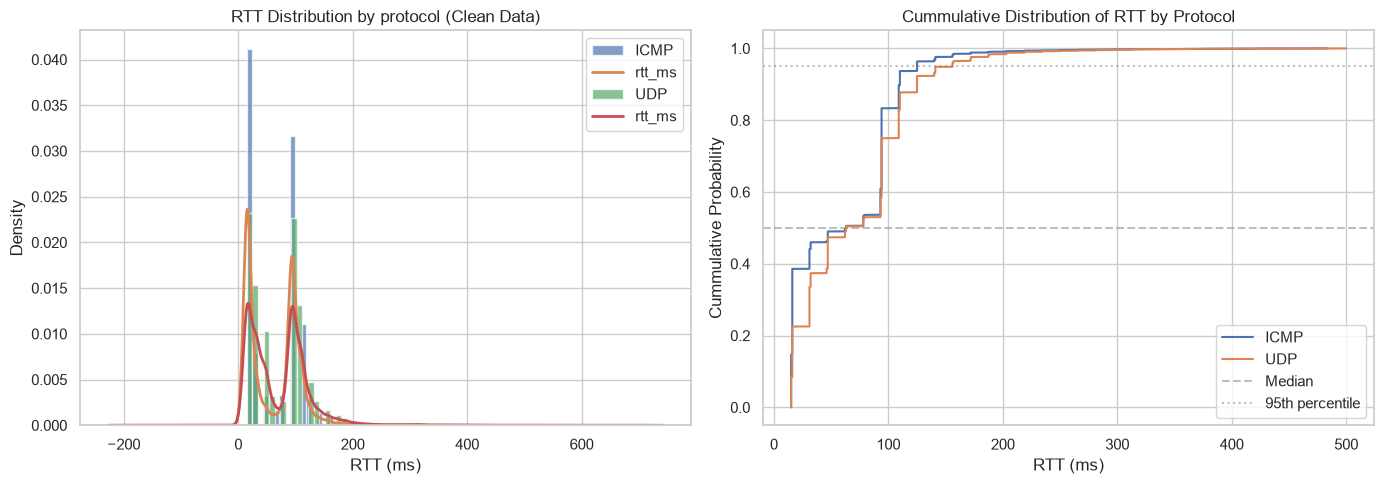

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#histogram with KDE
for proto in clean_df.protocol.unique():
    data = clean_df[clean_df.protocol == proto]['rtt_ms']
    axes[0].hist(data, bins=50, alpha=0.7, label=proto.upper(), density=True)
    data.plot.kde(ax=axes[0], linewidth=2)
axes[0].set_title("RTT Distribution by protocol (Clean Data)")
axes[0].set_xlabel("RTT (ms)")
axes[0].set_ylabel("Density")
axes[0].legend()

#CDF
for proto in clean_df.protocol.unique():
    data = clean_df[clean_df.protocol == proto]['rtt_ms'].sort_values()
    axes[1].plot(data, np.linspace(0, 1, len(data)), label=proto.upper())
axes[1].set_title("Cummulative Distribution of RTT by Protocol")
axes[1].set_xlabel("RTT (ms)")
axes[1].set_ylabel("Cummulative Probability")
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Median')
axes[1].axhline(y=0.95, color='gray', linestyle=':', alpha=0.5, label='95th percentile')
axes[1].legend()

plt.tight_layout()

In [18]:
print("RTT Statistics by Target: ")
target_stats = clean_df.groupby('dst_ip')['rtt_ms'].agg(['mean', 'median', 'std', 'min', 'count'])
target_stats.index = [TARGET_LABEL.get(ip, ip) for ip in target_stats.index]
print(target_stats)

RTT Statistics by Target: 
                                       mean  median        std   min  count
Cloudflare DNS (1.1.1.1)          32.758286    16.0  32.286957  15.0   6396
DNS.SB Europe (185.222.222.222)  105.316216    94.0  28.388603  78.0   8140
DNS.SB Europe (45.11.45.11)      107.915593    94.0  34.959984  78.0   8151
Google DNS (8.8.8.8)              36.287908    16.0  36.753605  15.0   7815
AdGuard DNS (94.140.14.14)        34.029683    16.0  35.566013  15.0   6603


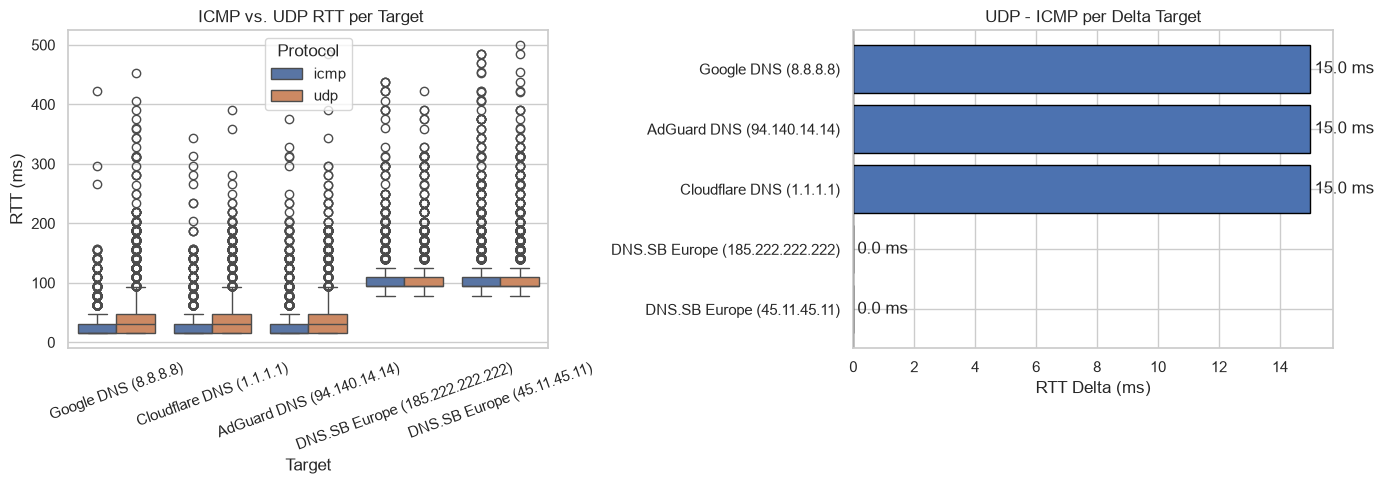

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#side by side box plot per protocol per target
clean_df['target_label'] = clean_df['dst_ip'].map(TARGET_LABEL)
sns.boxplot(data=clean_df, x='target_label', y='rtt_ms', hue='protocol', ax=axes[0])
axes[0].set_title(" ICMP vs. UDP RTT per Target")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("RTT (ms)")
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Protocol')

#UDP - ICMP per delta target
delta = clean_df.groupby(['target_label', 'protocol'])['rtt_ms'].median().unstack()
delta['delta'] = delta['udp'] - delta['icmp']
delta = delta.sort_values('delta')
bars = axes[1].barh(delta.index, delta['delta'], edgecolor='black')
axes[1].bar_label(bars, fmt='%.1f ms', padding=3)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title("UDP - ICMP per Delta Target")
axes[1].set_xlabel("RTT Delta (ms)")

plt.tight_layout()

UDP consistently shows higher RTT than ICMP across all targets, with a positive delta ranging from ~0ms to ~32ms depending on destination. This delta is our empirical estimate of D_proc — the additional processing overhead imposed by UDP's port unreachable mechanism (the destination must process the UDP packet, find no listener on port 33434, and generate an ICMP Port Unreachable response) versus ICMP Echo which is handled at the kernel level. European targets show larger deltas than nearby targets, suggesting that remote server processing overhead is more visible when propagation delay is already high. This per-target D_proc pattern will be used as a feature in the decomposition model.

In [20]:
udp_df = active_df[active_df.protocol == 'udp'].copy()

print("UDP success rate by target: ")
udp_target = udp_df.groupby('dst_ip')['success'].agg(['sum', 'count', 'mean'])
udp_target.columns = ['successful', 'total', 'success_rate']
udp_target.index = [TARGET_LABEL.get(ip, ip) for ip in udp_target.index]
print(udp_target)

print("\nUDP success rate by packet size: ")
print(udp_df.groupby('packet_size')['success'].mean())

UDP success rate by target: 
                                 successful  total  success_rate
Cloudflare DNS (1.1.1.1)               3175   4860      0.653292
DNS.SB Europe (185.222.222.222)        3295   4860      0.677984
DNS.SB Europe (45.11.45.11)            3305   4860      0.680041
Google DNS (8.8.8.8)                   4852   4860      0.998354
AdGuard DNS (94.140.14.14)             3169   4860      0.652058

UDP success rate by packet size: 
packet_size
64      0.776296
128     0.723704
256     0.722222
512     0.722469
1024    0.724198
1400    0.725185
Name: success, dtype: float64


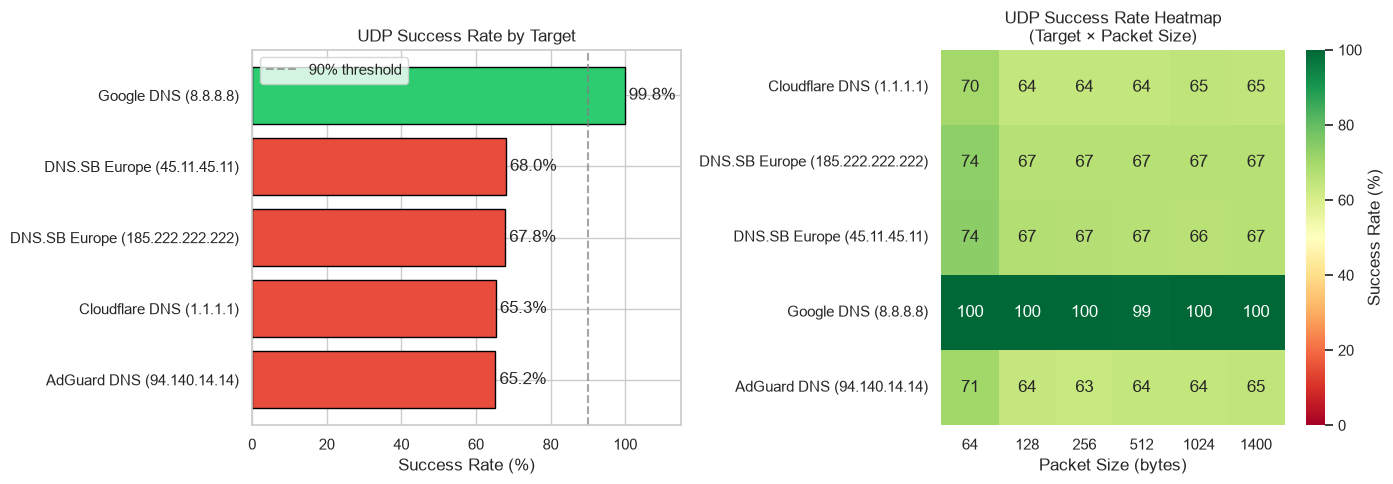

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#success rate by target
udp_by_target = udp_df.groupby('dst_ip')['success'].mean()*100
udp_by_target.index = [TARGET_LABEL.get(ip, ip) for ip in udp_by_target.index]
udp_by_target = udp_by_target.sort_values()
colors = ['#2ecc71' if v > 90 else '#e74c3c' for v in udp_by_target.values]
bars = axes[0].barh(udp_by_target.index, udp_by_target.values, color=colors, edgecolor='black')
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
axes[0].axvline(x=90, color='gray', linestyle='--', alpha=0.7, label='90% threshold')
axes[0].set_title('UDP Success Rate by Target')
axes[0].set_xlabel('Success Rate (%)')
axes[0].set_xlim(0, 115)
axes[0].legend()

# heatmap: success rate by target x packet size
udp_pivot = udp_df.groupby(['dst_ip','packet_size'])['success'].mean().unstack() * 100
udp_pivot.index = [TARGET_LABEL.get(ip, ip) for ip in udp_pivot.index]
sns.heatmap(udp_pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=axes[1], cbar_kws={'label': 'Success Rate (%)'})
axes[1].set_title('UDP Success Rate Heatmap\n(Target × Packet Size)')
axes[1].set_xlabel('Packet Size (bytes)')

plt.tight_layout()

UDP success rate for 8.8.8.8 is 99.8% but only 64-68% for all other targets. This pattern is target-specific, not packet-size-specific — the heatmap shows near-uniform failure rates across all packet sizes for the failing targets. This rules out fragmentation as the cause (fragmentation would show increasing failures at larger packet sizes). The most likely explanation is firewall policy: 1.1.1.1, 94.140.14.14, and the European targets silently drop UDP packets on port 33434 without returning an ICMP Port Unreachable response. 8.8.8.8 is the exception — Google's network reliably returns ICMP Port Unreachable. In preprocessing, UDP timeouts for non-8.8.8.8 targets must be flagged as firewall_drop rather than treated as congestion-induced failures, as they would corrupt D_queue estimates.

In [22]:
print("Avergae RTT by probe index (first 30 probes): ")
drift = clean_df.groupby('probe_index')['rtt_ms'].agg(['mean', 'median', 'std'])
print(drift)

Avergae RTT by probe index (first 30 probes): 
                  mean  median        std
probe_index                              
0            70.968800    78.0  55.136455
1            68.399516    63.0  53.556994
2            69.251015    78.0  49.633973
3            67.984151    78.0  49.970767
4            67.268412    78.0  46.561998
5            67.272655    63.0  49.110088
6            68.543860    78.0  48.056783
7            69.423886    78.0  50.753517
8            66.695545    62.0  52.299609
9            68.768533    78.0  53.305833
10           69.214286    79.0  49.055819
11           65.810074    47.0  50.587003
12           67.230238    78.0  47.729532
13           68.519591    78.0  49.286634
14           64.695082    47.0  50.326796
15           67.954078    78.0  47.096820
16           65.687861    62.0  49.155648
17           61.584416    47.0  47.005481
18           68.516626    79.0  49.019145
19           62.777157    47.0  46.307739
20           61.875304    47.

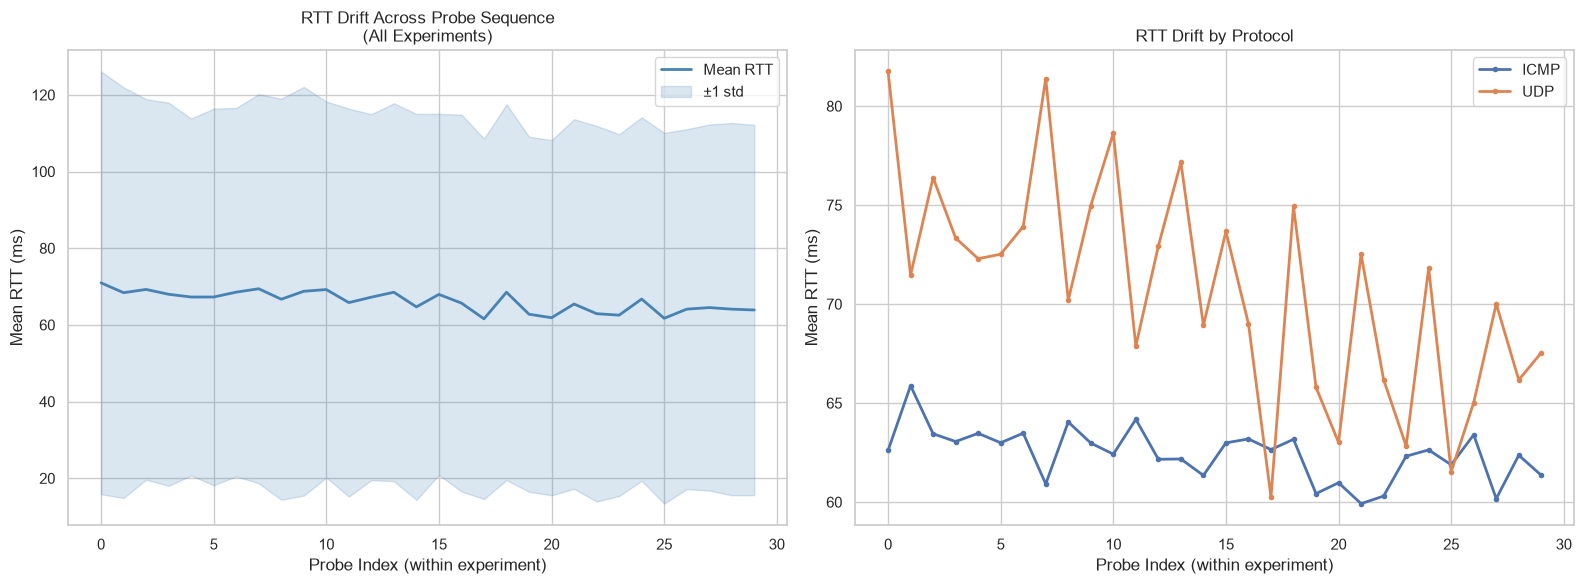

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# overall drift
drift_mean = clean_df.groupby('probe_index')['rtt_ms'].mean()
drift_std = clean_df.groupby('probe_index')['rtt_ms'].std()
axes[0].plot(drift_mean.index, drift_mean.values, color='steelblue', linewidth=2, label='Mean RTT')
axes[0].fill_between(drift_mean.index,
                     drift_mean.values - drift_std.values,
                     drift_mean.values + drift_std.values,
                     alpha=0.2, color='steelblue', label='±1 std')
axes[0].set_title('RTT Drift Across Probe Sequence\n(All Experiments)')
axes[0].set_xlabel('Probe Index (within experiment)')
axes[0].set_ylabel('Mean RTT (ms)')
axes[0].legend()

# drift per protocol
for proto in ['icmp','udp']:
    d = clean_df[clean_df.protocol==proto].groupby('probe_index')['rtt_ms'].mean()
    axes[1].plot(d.index, d.values, linewidth=2, label=proto.upper(), marker='o', markersize=3)
axes[1].set_title('RTT Drift by Protocol')
axes[1].set_xlabel('Probe Index (within experiment)')
axes[1].set_ylabel('Mean RTT (ms)')
axes[1].legend()

plt.tight_layout()

RTT shows a slight downward trend from probe index 0 (~56ms) to later probes (~45-52ms), then stabilizes. This is a warmup/caching effect — the first few probes in each experiment encounter ARP cache misses and routing table lookups, adding overhead that disappears once the network path is cached. This is the opposite of queuing buildup (which would show increasing RTT over probe sequence). The implication for preprocessing: probe_index == 0 should potentially be flagged or dropped as it systematically over-estimates baseline RTT. By probe index 3-4 the measurements stabilize, suggesting the true network RTT is measured from index 3 onward.

In [24]:
clean_df['hour'] = clean_df['timestamp'].dt.hour
clean_df['day_of_week'] = clean_df['timestamp'].dt.day_name()

print("RTT by Hour of day")
print(clean_df.groupby('hour')['rtt_ms'].agg(['mean', 'median', 'count']))

RTT by Hour of day
           mean  median  count
hour                          
0     36.471572    31.0    299
1     66.048980    62.0   4410
2     65.448179    93.0   3570
3     61.648835    47.0   1159
4     66.468349    78.0   8641
8     62.181916    47.0   9312
12    71.446469    78.0   9714


### PASSIVE CAPTURE 

In [25]:
print("Passive Capture Overview")
print(f"Total Packets Captured: {len(passive_df)}")
print(f"Unique Experiments: {passive_df.experiment_id.nunique()}")
print("\nProtocol Mix: ")
print(passive_df.protocol.value_counts(normalize=True) * 100)
print("\nPackets per experiment: ")
print(passive_df.groupby('experiment_id').size().describe())

Passive Capture Overview
Total Packets Captured: 472660
Unique Experiments: 2430

Protocol Mix: 
protocol
UDP      59.979266
TCP      27.236491
ICMP     12.777895
OTHER     0.006347
Name: proportion, dtype: float64

Packets per experiment: 
count    2430.000000
mean      194.510288
std       511.873110
min         8.000000
25%        32.000000
50%        62.000000
75%        85.000000
max      4622.000000
dtype: float64


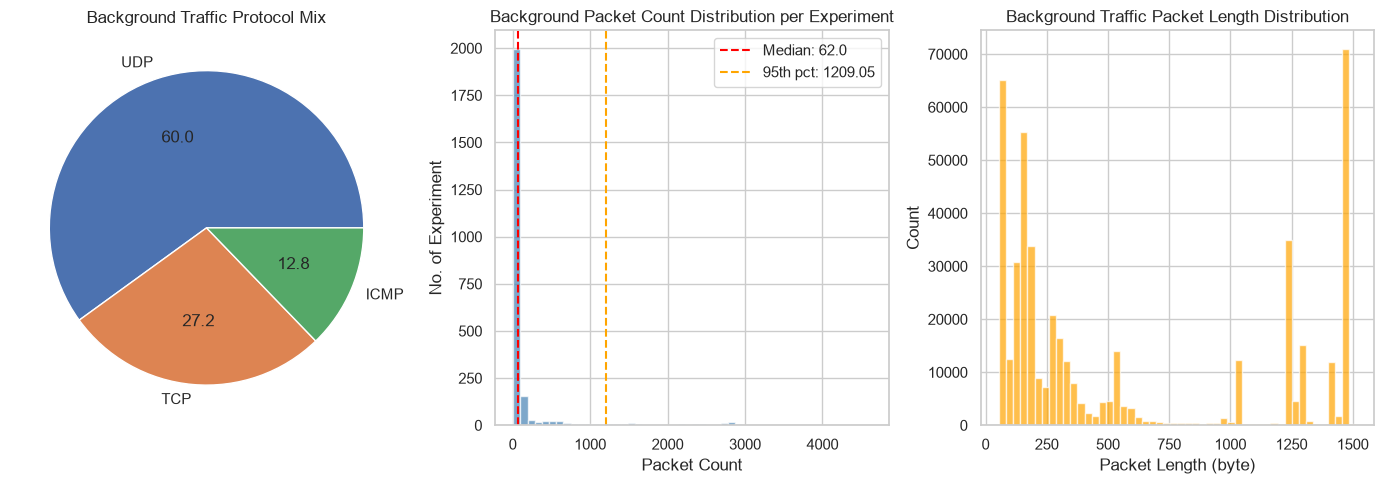

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

#protocol mix pie plot
proto_count = passive_df[passive_df.protocol != 'OTHER'].protocol.value_counts()
axes[0].pie(proto_count.values, labels=proto_count.index, autopct="%1.1f")
axes[0].set_title("Background Traffic Protocol Mix")

#background packet count distribution per experiment
bg_count = passive_df.groupby('experiment_id').size()
axes[1].hist(bg_count, bins=50, color='steelblue', alpha=0.7)
axes[1].axvline(bg_count.median(), color='red', linestyle='--', label=f'Median: {bg_count.median().round(2)}')
axes[1].axvline(bg_count.quantile(0.95), color='orange', linestyle='--', label=f'95th pct: {bg_count.quantile(0.95).round(2)}')
axes[1].set_title("Background Packet Count Distribution per Experiment")
axes[1].set_xlabel("Packet Count")
axes[1].set_ylabel("No. of Experiment")
axes[1].legend()

#packet length distribution
axes[2].hist(passive_df['packet_length'], bins=50, color='orange', alpha=0.7)
axes[2].set_title("Background Traffic Packet Length Distribution")
axes[2].set_xlabel("Packet Length (byte)")
axes[2].set_ylabel("Count")

plt.tight_layout()

Background traffic is split roughly 27.2% TCP, 12.8% ICMP, 60% UDP. The per-experiment packet count has a median of 62 packets but a highly skewed distribution with a maximum of 4622 — indicating occasional heavy background traffic spikes. These spike experiments should be flagged in preprocessing as potentially high-congestion windows. This mix of small control packets and large data packets is exactly what causes queuing delays in router buffers.

In [27]:
tcp_passive = passive_df[passive_df.protocol == 'TCP'].copy()
tcp_passive['window_size'] = tcp_passive['window_size'].fillna(0)

print("TCP Window Size Statistics: ")
print(tcp_passive['window_size'].describe())
print(f'\nWindow size < 1000 (buffer pressure): {(tcp_passive.window_size < 1000).sum()} ({(tcp_passive.window_size < 1000).mean()*100:.1f}%)')
print(f'Window size > 10000 (healthy buffer): {(tcp_passive.window_size > 10000).sum()} ({(tcp_passive.window_size > 10000).mean()*100:.1f}%)')

TCP Window Size Statistics: 
count    128736.000000
mean       3738.250031
std       10134.813023
min           0.000000
25%         255.000000
50%        1049.000000
75%        2050.000000
max       65535.000000
Name: window_size, dtype: float64

Window size < 1000 (buffer pressure): 58087 (45.1%)
Window size > 10000 (healthy buffer): 7983 (6.2%)


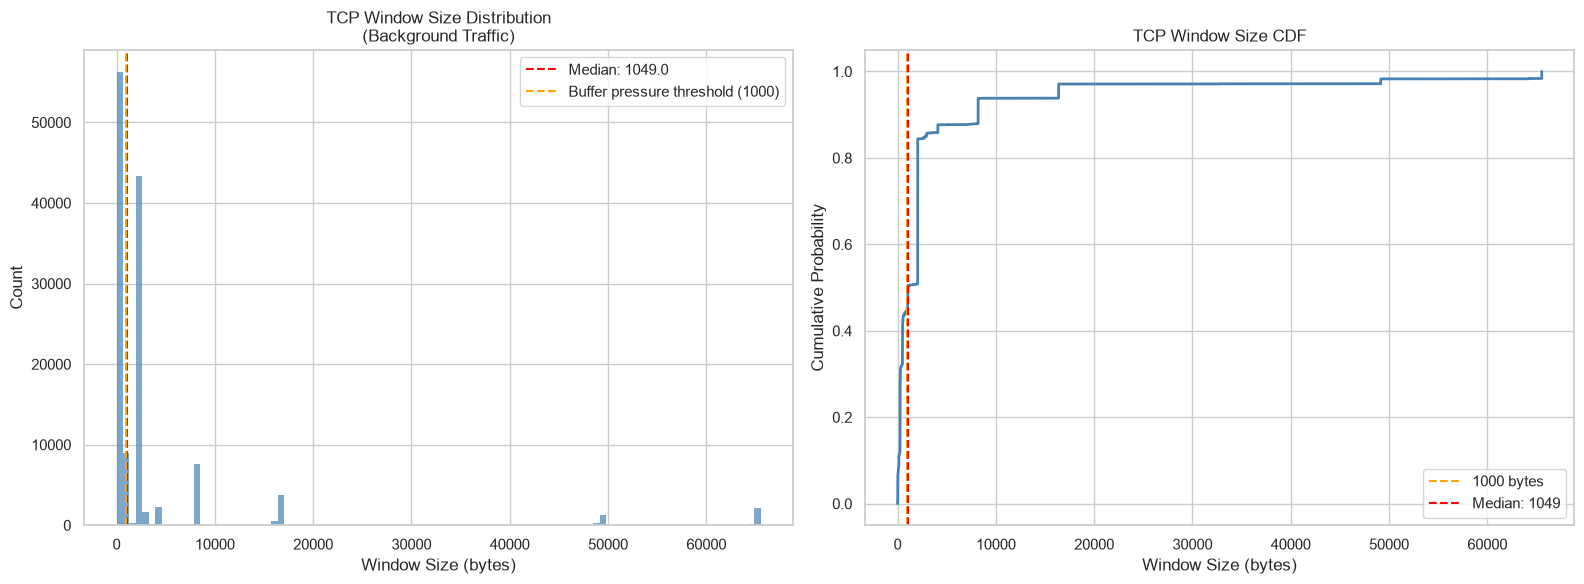

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#window size distribution
axes[0].hist(tcp_passive['window_size'], bins=100, color='steelblue', edgecolor='none', alpha=0.7)
axes[0].axvline(tcp_passive['window_size'].median(), color='red', linestyle='--', 
                label=f'Median: {tcp_passive["window_size"].median()}')
axes[0].axvline(1000, color='orange', linestyle='--', label='Buffer pressure threshold (1000)')
axes[0].set_title('TCP Window Size Distribution\n(Background Traffic)')
axes[0].set_xlabel('Window Size (bytes)')
axes[0].set_ylabel('Count')
axes[0].legend()

#window size CDF
sorted_ws = np.sort(tcp_passive['window_size'])
axes[1].plot(sorted_ws, np.linspace(0, 1, len(sorted_ws)), color='steelblue', linewidth=2)
axes[1].axvline(1000, color='orange', linestyle='--', label='1000 bytes')
axes[1].axvline(tcp_passive['window_size'].median(), color='red', linestyle='--',
                label=f'Median: {tcp_passive["window_size"].median():.0f}')
axes[1].set_title('TCP Window Size CDF')
axes[1].set_xlabel('Window Size (bytes)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend()

plt.tight_layout()

The median TCP window size is only 1049 bytes — extremely small. 45.1% of all background TCP packets have window sizes below 1000 bytes, indicating persistent receiver buffer pressure across the network. A small TCP window size means the receiver is telling the sender to slow down because its buffer is filling up — a direct indicator of D_queue conditions. This is one of the strongest congestion signals in the passive dataset. In the feature engineering phase, mean_window_size and min_window_size per experiment will be key features for estimating D_queue.

In [29]:
#aggregate passive features per experiment
passive_features = passive_df.groupby('experiment_id').agg(
    bg_packet_count=('timestamp', 'count'), total_byte_volume=('packet_length', 'sum'), mean_packet_length=('packet_length', 'mean'),
    median_ttl=('ttl', 'median'), mean_window_size=('window_size', 'mean'), min_window_size=('window_size', 'min'),
    std_window_size=('window_size', 'min'), bg_tcp_ratio=('protocol', lambda x: (x == 'TCP').mean()),
    bg_udp_ratio=('protocol', lambda x: (x == 'UDP').mean())).reset_index()

passive_features['std_window_size'] = passive_features['std_window_size'].fillna(0)
passive_features['mean_window_size'] = passive_features['mean_window_size'].fillna(0)
passive_features['min_window_size'] = passive_features['min_window_size'].fillna(0)

In [30]:
#merge passive with clean active data
master_df = pd.merge(clean_df, passive_features, on='experiment_id', how='inner')

print(f'Master analytical matrix shape: {master_df.shape}')
print(f'Features available: {list(master_df.columns)}')

Master analytical matrix shape: (37105, 23)
Features available: ['timestamp', 'experiment_id', 'source_location', 'protocol', 'dst_ip', 'packet_size', 'probe_index', 'success', 'rtt_ms', 'send_timestamp', 'recv_timestamp', 'target_label', 'hour', 'day_of_week', 'bg_packet_count', 'total_byte_volume', 'mean_packet_length', 'median_ttl', 'mean_window_size', 'min_window_size', 'std_window_size', 'bg_tcp_ratio', 'bg_udp_ratio']


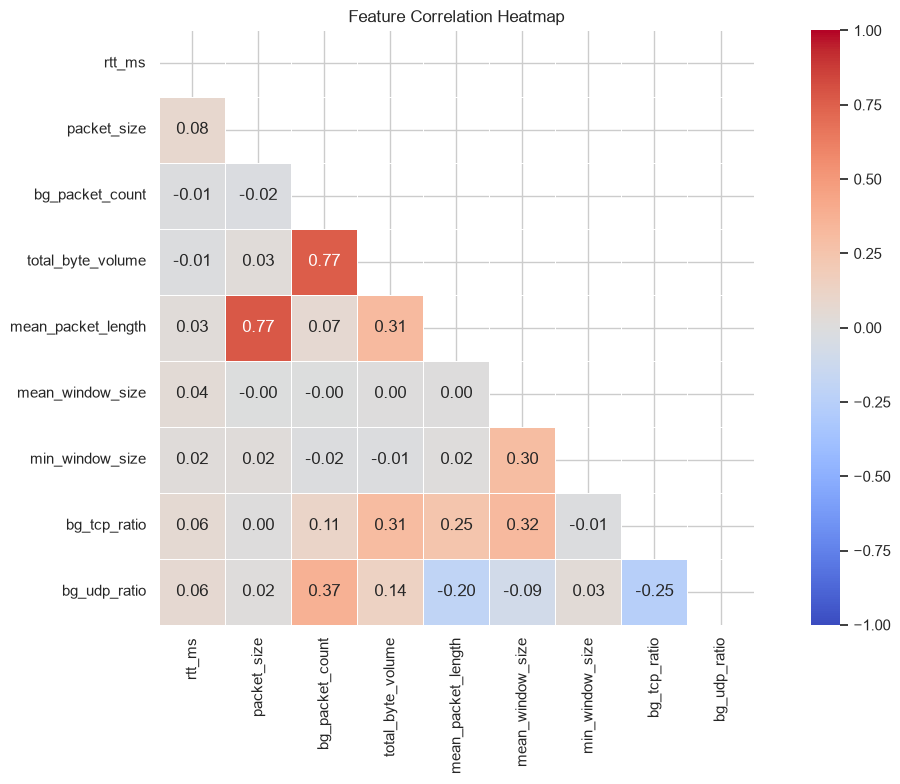

In [31]:
#correlation matrix
corr_cols = ['rtt_ms', 'packet_size', 'bg_packet_count', 'total_byte_volume', 'mean_packet_length', 'mean_window_size', 
             'min_window_size', 'bg_tcp_ratio', 'bg_udp_ratio']
corr_matrix = master_df[corr_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, mask=mask, square=True, linewidth=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()

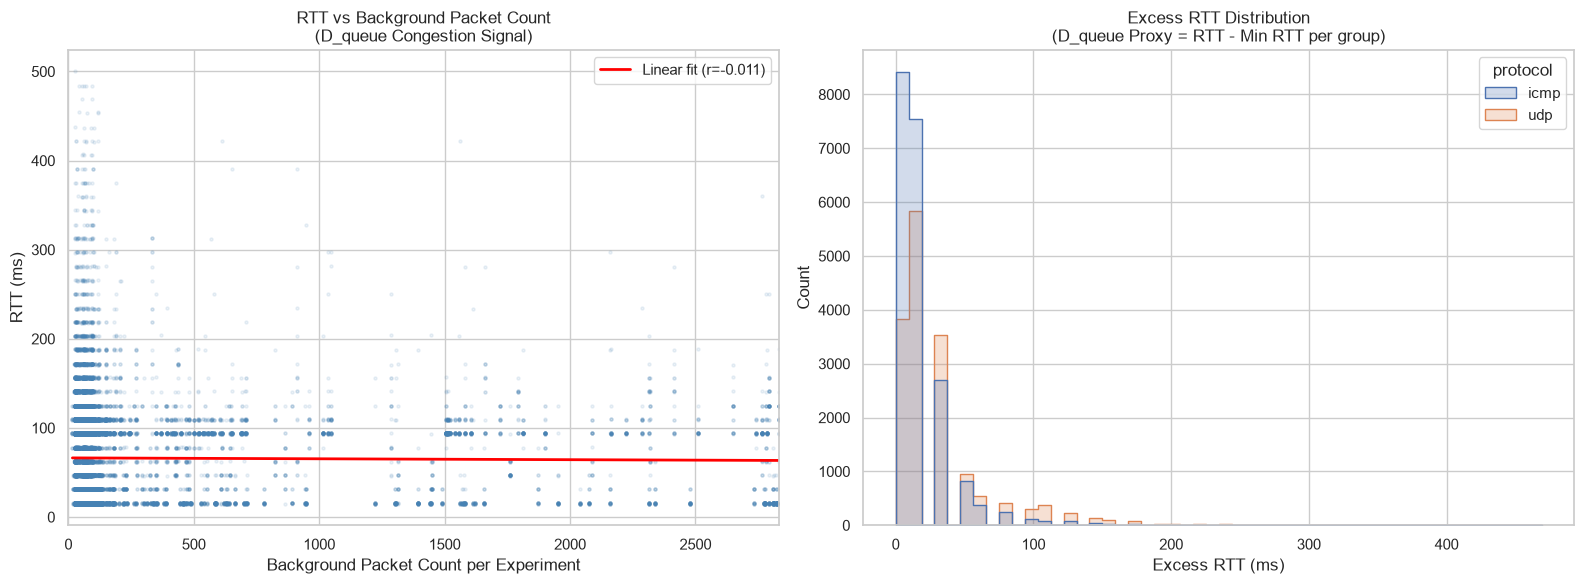

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RTT vs background packet count 
axes[0].scatter(master_df['bg_packet_count'], master_df['rtt_ms'], alpha=0.1, color='steelblue', s=5)
slope, intercept, r, p, _ = stats.linregress(master_df['bg_packet_count'], master_df['rtt_ms'])
x = np.linspace(master_df['bg_packet_count'].min(), master_df['bg_packet_count'].quantile(0.99))
axes[0].plot(x, slope*x + intercept, color='red', linewidth=2, label=f'Linear fit (r={r:.3f})')
axes[0].set_xlim(0, master_df['bg_packet_count'].quantile(0.99))
axes[0].set_title('RTT vs Background Packet Count\n(D_queue Congestion Signal)')
axes[0].set_xlabel('Background Packet Count per Experiment')
axes[0].set_ylabel('RTT (ms)')
axes[0].legend()

# excess RTT (D_queue proxy)
master_df['min_rtt'] = master_df.groupby(['dst_ip','protocol','packet_size'])['rtt_ms'].transform('min')
master_df['excess_rtt'] = master_df['rtt_ms'] - master_df['min_rtt']
sns.histplot(data=master_df, x='excess_rtt', hue='protocol', bins=50, element='step', ax=axes[1])
axes[1].set_title('Excess RTT Distribution\n(D_queue Proxy = RTT - Min RTT per group)')
axes[1].set_xlabel('Excess RTT (ms)')
axes[1].set_ylabel('Count')

plt.tight_layout()